# House Price Prediction — Exploratory Data Analysis

Regression on the Ames Housing dataset (1,460 homes, 80 features) predicting `SalePrice`. Features cover lot size, neighborhood, construction quality, year built, garage, basement, and more. A canonical Kaggle competition for tabular regression.

**Target:** `SalePrice` (continuous)

## 1. Imports & Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [9]:
df = pd.read_csv('data/train.csv')
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
print('Shape:', df.shape)
df.head()

Shape: (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Dataset Overview

In [10]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (1460, 80)

Dtypes:
object     43
int64      34
float64     3
Name: count, dtype: int64


In [11]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
Street,1460,2,Pave,1454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,91,2,Grvl,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1460,4,Reg,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1460,4,Lvl,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1460,2,AllPub,1459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotConfig,1460,5,Inside,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 0
Memory (MB): 3.42


## 3. Missing / Invalid Values

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

              Missing  Percent
PoolQC           1453    99.52
MiscFeature      1406    96.30
Alley            1369    93.77
Fence            1179    80.75
MasVnrType        872    59.73
FireplaceQu       690    47.26
LotFrontage       259    17.74
GarageType         81     5.55
GarageYrBlt        81     5.55
GarageFinish       81     5.55
GarageQual         81     5.55
GarageCond         81     5.55
BsmtExposure       38     2.60
BsmtFinType2       38     2.60
BsmtQual           37     2.53
BsmtCond           37     2.53
BsmtFinType1       37     2.53
MasVnrArea          8     0.55
Electrical          1     0.07


## 4. Target Variable Distribution

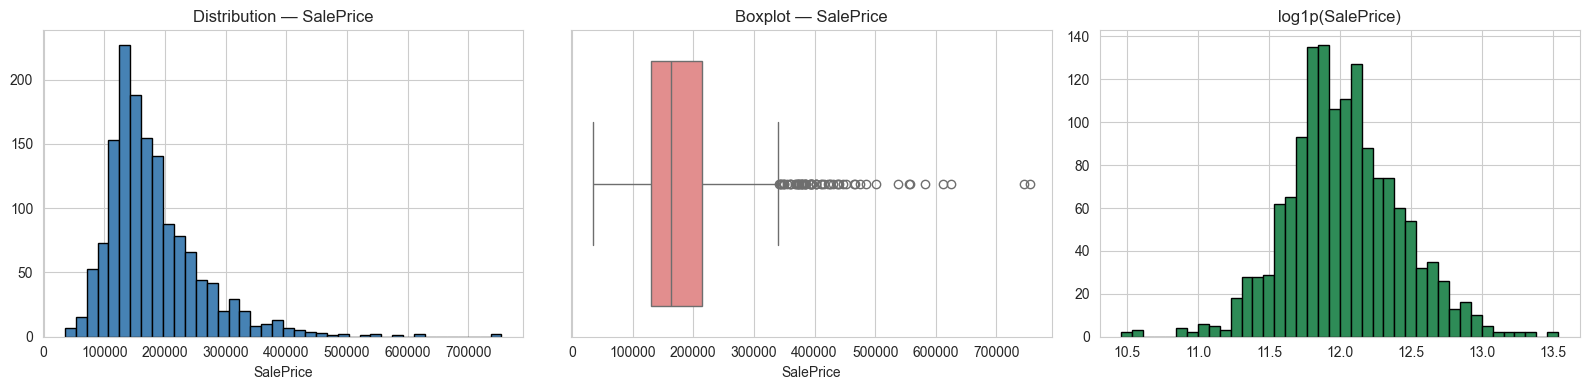

Skewness : 1.883
Kurtosis : 6.536
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['SalePrice'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — SalePrice')
axes[0].set_xlabel('SalePrice')
sns.boxplot(x=df['SalePrice'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — SalePrice')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['SalePrice'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(SalePrice)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['SalePrice'].skew(), 3))
print('Kurtosis :', round(df['SalePrice'].kurtosis(), 3))
print(df['SalePrice'].describe().round(2))

## 7. Correlation Analysis

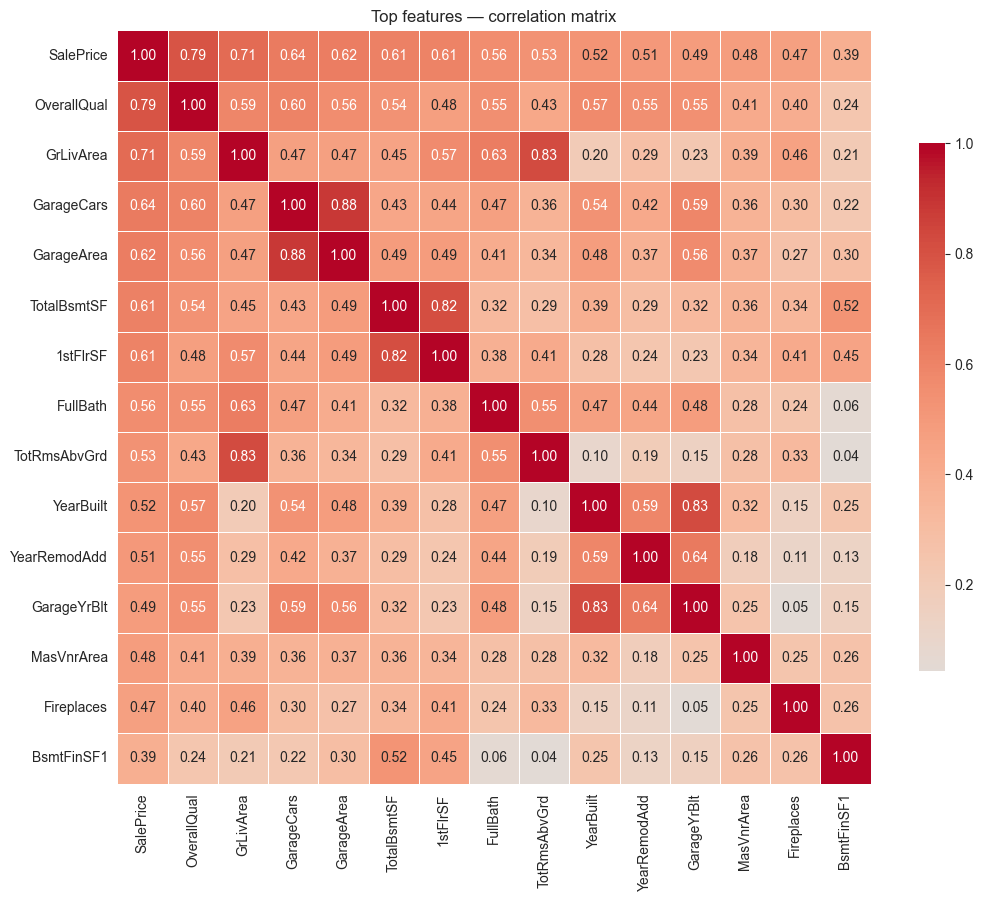

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corrs_all = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
top_numeric = corrs_all.head(15).index.tolist()
if 'SalePrice' not in top_numeric:
    top_numeric.append('SalePrice')

# 4. Plot the heatmap
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
target_corr = df[numeric_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with SalePrice')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

In [ ]:
if 'Neighborhood' in df.columns:
    nb_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()
    plt.figure(figsize=(12, 6))
    nb_price.plot(kind='barh', color='coral')
    plt.title('Mean SalePrice by Neighborhood'); plt.xlabel('Mean SalePrice')
    plt.tight_layout(); plt.show()

## 10. Summary of Key Findings

In [18]:
top_features = corrs_all.drop('SalePrice').index.tolist()
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['SalePrice'].mean(), 2),
        round(df['SalePrice'].median(), 2),
        round(df['SalePrice'].std(), 2),
        round(df['SalePrice'].min(), 2),
        round(df['SalePrice'].max(), 2),
        round(df['SalePrice'].skew(), 3),
        top_features[0],                      # Now this will work
        round(corrs_all[top_features[0]], 3), # Now this will work
    ],
})
summary

,Metric,Value
0,Total samples,1460
1,Total features,79
2,Target mean,180921.2
3,Target median,163000.0
4,Target stddev,79442.5
5,Target min,34900
6,Target max,755000
7,Target skewness,1.883
8,Top correlated feature,OverallQual
9,Top correlation value,0.791
